Conditions
* 10: 2 hour GC incubation, 6uL M.CviPI in 200 uL Hia5 buffer
* 11: 15 min. GC incubation, 6uL M.CviPI in 200 uL Hia5 buffer
* 12: nanoNOMe incubation, 15 min. GC incubation, 50uL M.CviPI in 500 uL nanoNOMe buffer, lots of nuclei
* 13: no-accessibility control
* 14: nanoNOMe incubation, 15 min. GC incubation, 50uL M.CviPI in 500 uL nanoNOMe buffer, 500k nuclei

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

import config, plotting
from dimelo import parse_bam, plot_enrichment_profile, load_processed

In [2]:
reference_file = config.raw_data_dir / "chm13v2.0.fa"
ctcf_bed_file = config.processed_data_dir / "gm12878_ctcf_motif_intersect_chip.top3k.bed"
ctcf_on_target_bed_file = config.processed_data_dir / "gm12878_ctcf.on_target.bed"
bam_dir = config.processed_data_dir / "20240831_GpC_CpG_crosstalk_demuxed"
barcodes = [10, 11, 12, 13]

# NOTE: Match window sizes set in third_party_data.ipynb
window_size = 1500
ctcf_on_target_window_size = 200
motifs = ["A,0", "GCH,1", "GCH,1,h", "WCG,1", "WCG,1,h"]
mod_prob_thresh = 0.75
smoothing = 25
n_cores = 10

y_lim = (-0.01, 0.6)

In [3]:
for barcode in barcodes:
    bam_file = bam_dir / f"barcode{barcode}.bam"
    # TODO: This should be renamed so that there is no risk of overlapping with demuxed files from another dataset; maybe make a subdirectory?
    output_id = f"{bam_file.stem}.{ctcf_bed_file.stem}.thresh75"
    parse_bam.pileup(
        input_file=bam_file,
        output_name=f"pileup.{output_id}",
        ref_genome=reference_file,
        output_directory=config.processed_data_dir,
        regions=ctcf_bed_file,
        motifs=motifs,
        thresh=mod_prob_thresh,
        window_size=window_size,
        cores=n_cores,
        override_checks=True
    )
    parse_bam.extract(
        input_file=bam_file,
        output_name=f"extract.{bam_file.stem}.gm12878_ctcf.on_target",
        ref_genome=reference_file,
        output_directory=config.processed_data_dir,
        regions=ctcf_on_target_bed_file,
        motifs=motifs,
        thresh=None, # No thresholding at extract time
        window_size=None,
        cores=n_cores,
        override_checks=True,
    )

Allocating requested 10 cores.
Modification threshold of 0.75 will be treated as coming from range 0-1.


          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in barcode10.bam   0% | 00:00<?

          |    0%

Allocating requested 10 cores.
No valid base modification threshold provided. Raw probs will be saved.


...

          | Transferring 2487 from reads.WCG,1.txt into reads.combined_basemods.h5, new size 10817   0% | 00:0…

          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in barcode13.bam   0% | 00:00<?

          |    0%

          | Transferring 2487 from reads.WCG,1,h.txt into reads.combined_basemods.h5, new size 13304   0% | 00…

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

...

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

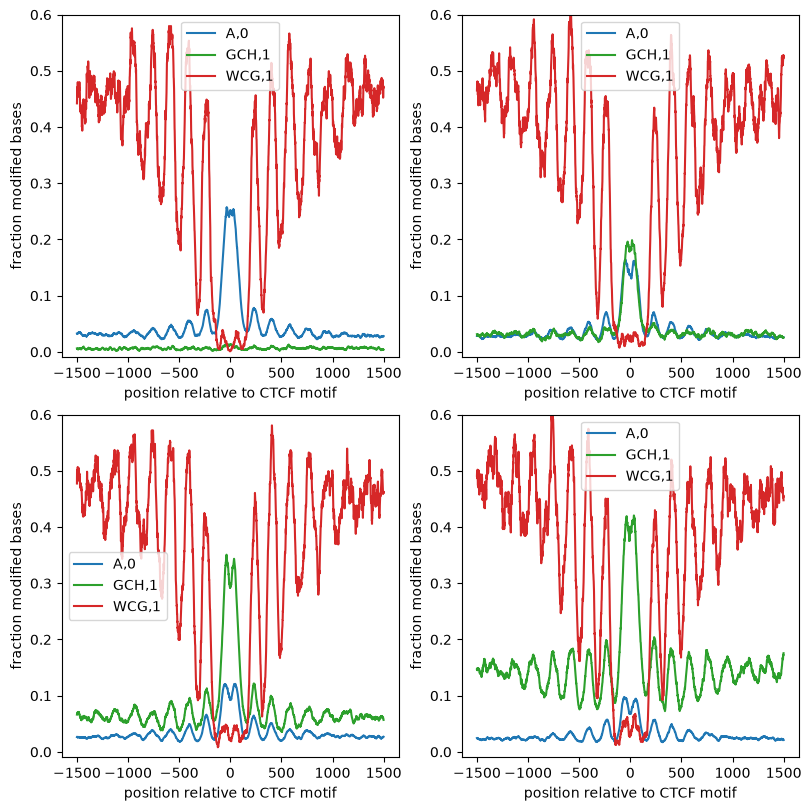

In [3]:
_, axs = plt.subplots(2, 2, figsize=(8, 8), layout="constrained")
for barcode, ax in zip([13, 11, 10, 12], np.ravel(axs)):
    bam_file = bam_dir / f"barcode{barcode}.bam"
    # TODO: This should be renamed so that there is no risk of overlapping with demuxed files from another dataset; maybe make a subdirectory?
    output_id = f"{bam_file.stem}.{ctcf_bed_file.stem}"
    plot_enrichment_profile.by_modification(
        config.processed_data_dir / f"pileup.{output_id}.thresh75" / "pileup.sorted.bed.gz",
        regions=ctcf_bed_file,
        motifs=["A,0","GCH,1", "WCG,1"],
        window_size=window_size,
        smooth_window=smoothing,
        palette=plotting.default_palette_map,
        ax=ax
    )
    ax.set_xlabel("position relative to CTCF motif")
    ax.set_ylim(y_lim)
    ax.legend(title="")

plt.savefig(config.figure_dir / "crosstalk.plot_enrichment_profile.svg")
plt.show()
plt.close()

# Supplemental Figures

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

...

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

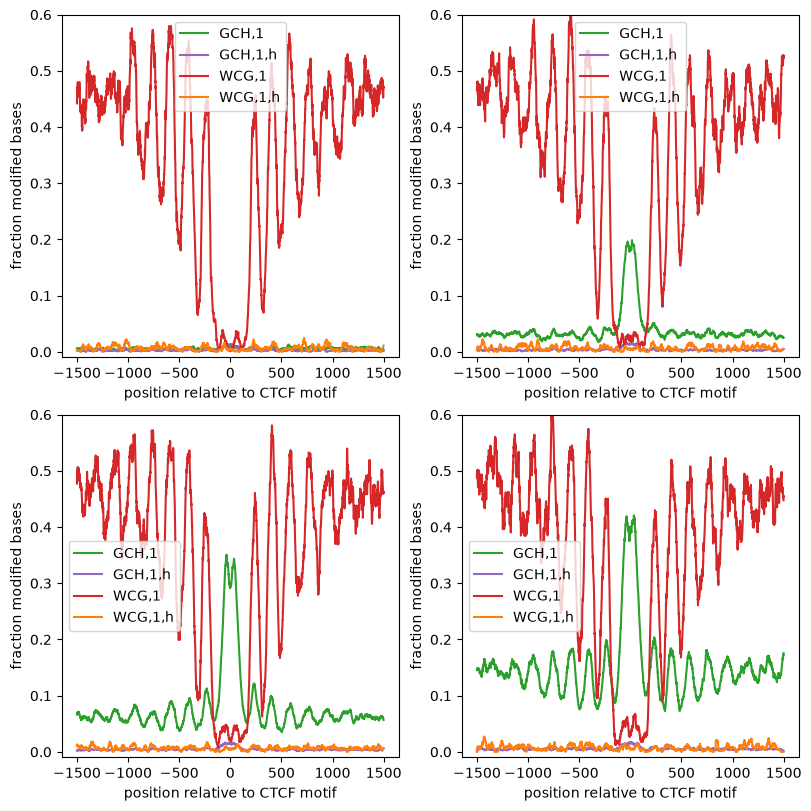

In [4]:
_, axs = plt.subplots(2, 2, figsize=(8, 8), layout="constrained")
for barcode, ax in zip([13, 11, 10, 12], np.ravel(axs)):
    bam_file = bam_dir / f"barcode{barcode}.bam"
    # TODO: This should be renamed so that there is no risk of overlapping with demuxed files from another dataset; maybe make a subdirectory?
    output_id = f"{bam_file.stem}.{ctcf_bed_file.stem}"
    plot_enrichment_profile.by_modification(
        config.processed_data_dir / f"pileup.{output_id}.thresh75" / "pileup.sorted.bed.gz",
        regions=ctcf_bed_file,
        motifs= ["GCH,1", "GCH,1,h", "WCG,1", "WCG,1,h"],
        window_size=window_size,
        smooth_window=smoothing,
        palette=plotting.default_palette_map,
        ax=ax
    )
    ax.set_xlabel("position relative to CTCF motif")
    ax.set_ylim(y_lim)
    ax.legend(title="")

plt.savefig(config.figure_dir / "crosstalk.plot_enrichment_profile.5hmC.svg")
plt.show()
plt.close()

In [5]:
from collections import defaultdict
from scipy import stats, special
from scipy.spatial import distance

In [6]:
# Load read extractions
# TODO: should only do loading one time, before plotting or performing tests
motif_mod_vectors = defaultdict(list)
for motif in motifs:
    for barcode in [13, 11, 10, 12]:
        bam_file = bam_dir / f"barcode{barcode}.bam"
        file_path = config.processed_data_dir / f"extract.{bam_file.stem}.gm12878_ctcf.on_target" / "reads.combined_basemods.h5"
        read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
            file=file_path,
            motifs=[motif],
            regions=ctcf_on_target_bed_file,
            single_strand=False,
            sort_by="shuffle",
            calculate_mod_fractions=False,
        )
        mod_vector_index = entry_labels.index("mod_vector")
        val_vector_index = entry_labels.index("val_vector")
        mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
        motif_mod_vectors[motif].append(mod_vector)

In [7]:
from io import BytesIO
import subprocess
modkit_exe = "/Users/jeremy/devspace/cargo_local/bin/modkit"

import pandas as pd

Setting up for probability distribution comparisons

In [8]:
# 256 equally spaced values between 0 and 1, with standard correction
mod_prob_pmf_values = (np.linspace(0, 1, 257) - ((0 + 0.5) / 256))[1:]

In [9]:
def mod_prob_pmf(mod_prob_vector: np.ndarray) -> np.ndarray:
    """
    Returns a vector containing PMF corresponding to the given mod prob vector.

    Guaranteed to return a normalized 256 element array.
    """
    hist, _ = np.histogram(mod_prob_vector, bins=256, range=(0, 1))
    return(hist / np.sum(hist))


In [10]:
motif_mod_pmfs = {motif: [mod_prob_pmf(v) for v in mod_vecs] for motif, mod_vecs in motif_mod_vectors.items()}

Wasserstein bootstrap

In [11]:
bootstrap_results = defaultdict(list)
for motif in motifs:
    for i in range(4):
        # TODO: using method "basic" because "BCa" crashed the kernel. Is this reasonable?
        data = (motif_mod_vectors[motif][0], motif_mod_vectors[motif][i])
        bootstrap_result = stats.bootstrap(data, stats.wasserstein_distance, vectorized=False, rng=42, n_resamples=1000, method="basic")
        bootstrap_results[motif].append(bootstrap_result)

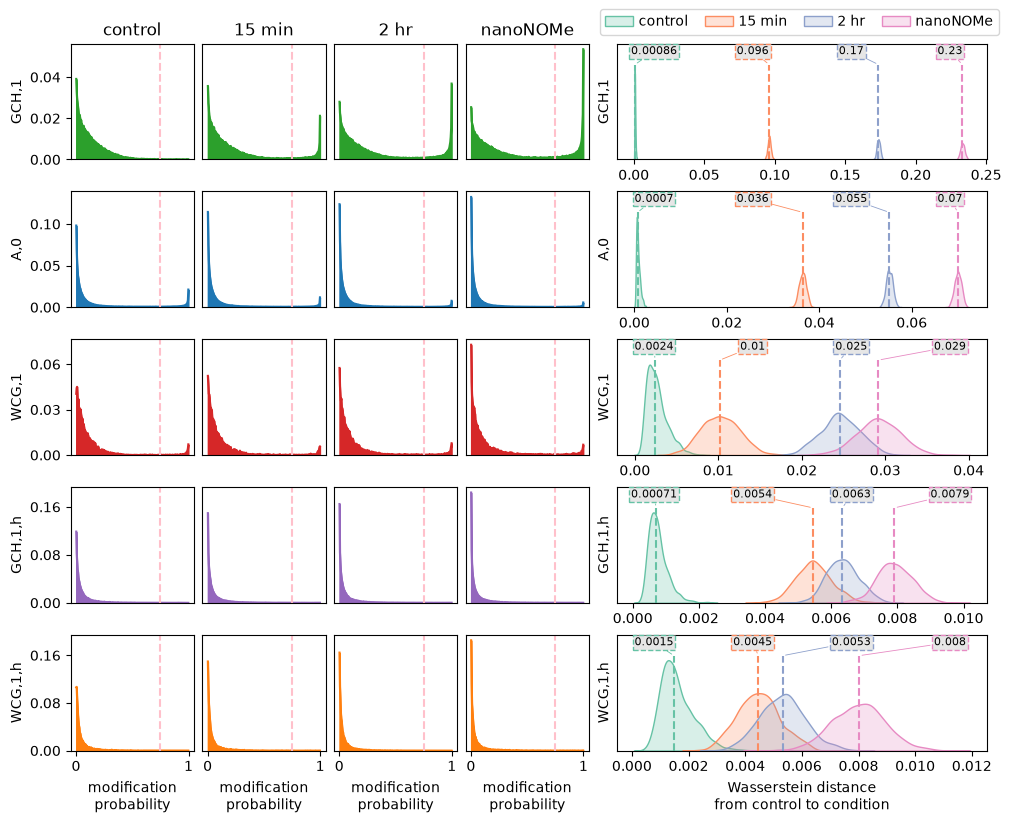

In [14]:
labels = ["control", "15 min", "2 hr", "nanoNOMe"]
experiment_pallete = sns.color_palette("Set2")
motifs = ["GCH,1", "A,0", "WCG,1", "GCH,1,h", "WCG,1,h"]


def label_strip(ax, medians, colors, strip_frac=0.16, edge_frac=0.10, fs=8):
    """Evenly-spaced value labels in a strip above the curves, each with a
    leader line to its median. Sorted so leaders never cross; expands ylim."""
    grey = (0.9, 0.9, 0.9)
    y0, y1 = ax.get_ylim()
    yr = y1 - y0
    ax.set_ylim(y0, y1 + strip_frac * yr + 0.06 * yr)
    xr = ax.get_xlim(); xw = xr[1] - xr[0]
    y_text = y1 + (strip_frac * 0.5 + 0.06) * yr
    slots = np.linspace(xr[0] + edge_frac * xw, xr[1] - edge_frac * xw, len(medians))
    ax.vlines(medians, 0, y1, colors=colors, linestyle="--", zorder=1)
    for slot_i, idx in enumerate(np.argsort(medians)):
        ax.annotate(f"{medians[idx]:.2}", xy=(medians[idx], y1),
                    xytext=(slots[slot_i], y_text), ha="center", va="center",
                    fontsize=fs, zorder=4,
                    bbox=dict(ec=colors[idx], fc=grey, linestyle="--", pad=1.4),
                    arrowprops=dict(arrowstyle="-", color=colors[idx], lw=0.6,
                                    shrinkA=1, shrinkB=2))


# 4x4 grid of distributions, 4x3 grid of kdes
mosaic = [[f"{motif}:dist:{i}" for i in range(4)] + [f"{motif}:kde"] * 3 for motif in motifs]
fig, axs_dict = plt.subplot_mosaic(mosaic, layout="constrained", figsize=(10, 8))

for motif_idx, motif in enumerate(motifs):
    # Distributions
    for i, label in enumerate(labels):
        ax = axs_dict[f"{motif}:dist:{i}"]
        sns.lineplot(x=mod_prob_pmf_values, y=motif_mod_pmfs[motif][i], ax=ax, color=plotting.default_palette_map[motif])
        ax.fill_between(mod_prob_pmf_values, motif_mod_pmfs[motif][i], color=plotting.default_palette_map[motif])
        if motif_idx == 0:
            ax.set_title(labels[i])
        if motif_idx != 4:
            ax.set_xticks([])
        else:
            ax.set_xlabel("modification\nprobability")
        # labeled y ticks only on the leftmost dist plot of each row
        if i == 0:
            ax.set_ylabel(motif)
            ax.yaxis.set_major_locator(mticker.MaxNLocator(3))
        else:
            ax.set_yticks([])
        ax.axvline(mod_prob_thresh, linestyle="--", color="pink")

    # Shared y limits across the row
    dist_axes = [axs_dict[f"{motif}:dist:{i}"] for i in range(4)]
    row_ymax = max(np.max(motif_mod_pmfs[motif][i]) for i in range(4))
    for ax in dist_axes:
        ax.set_ylim(0, row_ymax * 1.05)

    # KDEs
    ax = axs_dict[f"{motif}:kde"]
    mod_vectors = motif_mod_vectors[motif]
    wds, medians = [], []
    for i in range(4):
        wd = stats.wasserstein_distance(mod_vectors[0], mod_vectors[i])
        sns.kdeplot(bootstrap_results[motif][i].bootstrap_distribution, label=f"{labels[i]}", color=experiment_pallete[i], fill=True, ax=ax)
        wds.append(wd)
        medians.append(np.median(bootstrap_results[motif][i].bootstrap_distribution))
    label_strip(ax, medians, experiment_pallete[:4])
    ax.set_ylabel(motif)
    ax.set_xlabel("")
    ax.set_yticks([])
    if motif_idx == 4:
        ax.set_xlabel("Wasserstein distance\nfrom control to condition")

# Shared condition legend as a figure legend along the top
handles, leg_labels = axs_dict["GCH,1:kde"].get_legend_handles_labels()
fig.legend(handles, leg_labels, ncols=4, loc="upper right",
           bbox_to_anchor=(1.0, 1.02), frameon=True,
           handletextpad=0.4, columnspacing=1.2)

plt.savefig(config.figure_dir / "crosstalk_supplement.svg", bbox_inches="tight")
plt.show()
plt.close()